# Tutorial: Simple Legal Contract Review Workflow with AgentGrid SDKs
- Author: Shridhar Kini
- To Securely Run: `jupyter notebook password` to generate onetime password for secure access
- To Run at root directory of the repo: `jupyter notebook --allow-root --port 9999 --ip=0.0.0.0` 
- To Clear Outputs: Use `jupyter nbconvert --clear-output --inplace Simple_workflow.ipynb` 

This walkthrough demonstrates how to build and orchestrate a sequential workflow of agents using the **AgentGrid SDKs** and **AgentGrid Workflow Engine**. We focus on a **Legal Contract Review Workflow**, where a contract passes through 5 specialized agents. Workflows help in binding agent flows without hardcoding data routing directly into the agent code or YAML, allowing the path of data movements to be constructed dynamically at run time.

## 1. Directory Structure
Understanding the files in this demonstration:
* **`nodes/`**: Contains the Python code for each agent (`clause_extractor_agent.py`, `risk_identifier_agent.py`, `compliance_checker_agent.py`, `negotiation_adviser_agent.py`, `legal_memo_agent.py`).
* **`spec/`**: Contains agent registration JSON specifications (`agent_clause_extractor.json`, etc.) and bash scripts for agent-level operations (registering, deploying, removing, unregistering).
* **`deploy_run/`**: Contains the `workflow_spec.json` (which defines the data flow between the agents), the Streamlit dashboard code (`streamlit_app.py`, `structure`), and the bash scripts for workflow orchestration and inference.

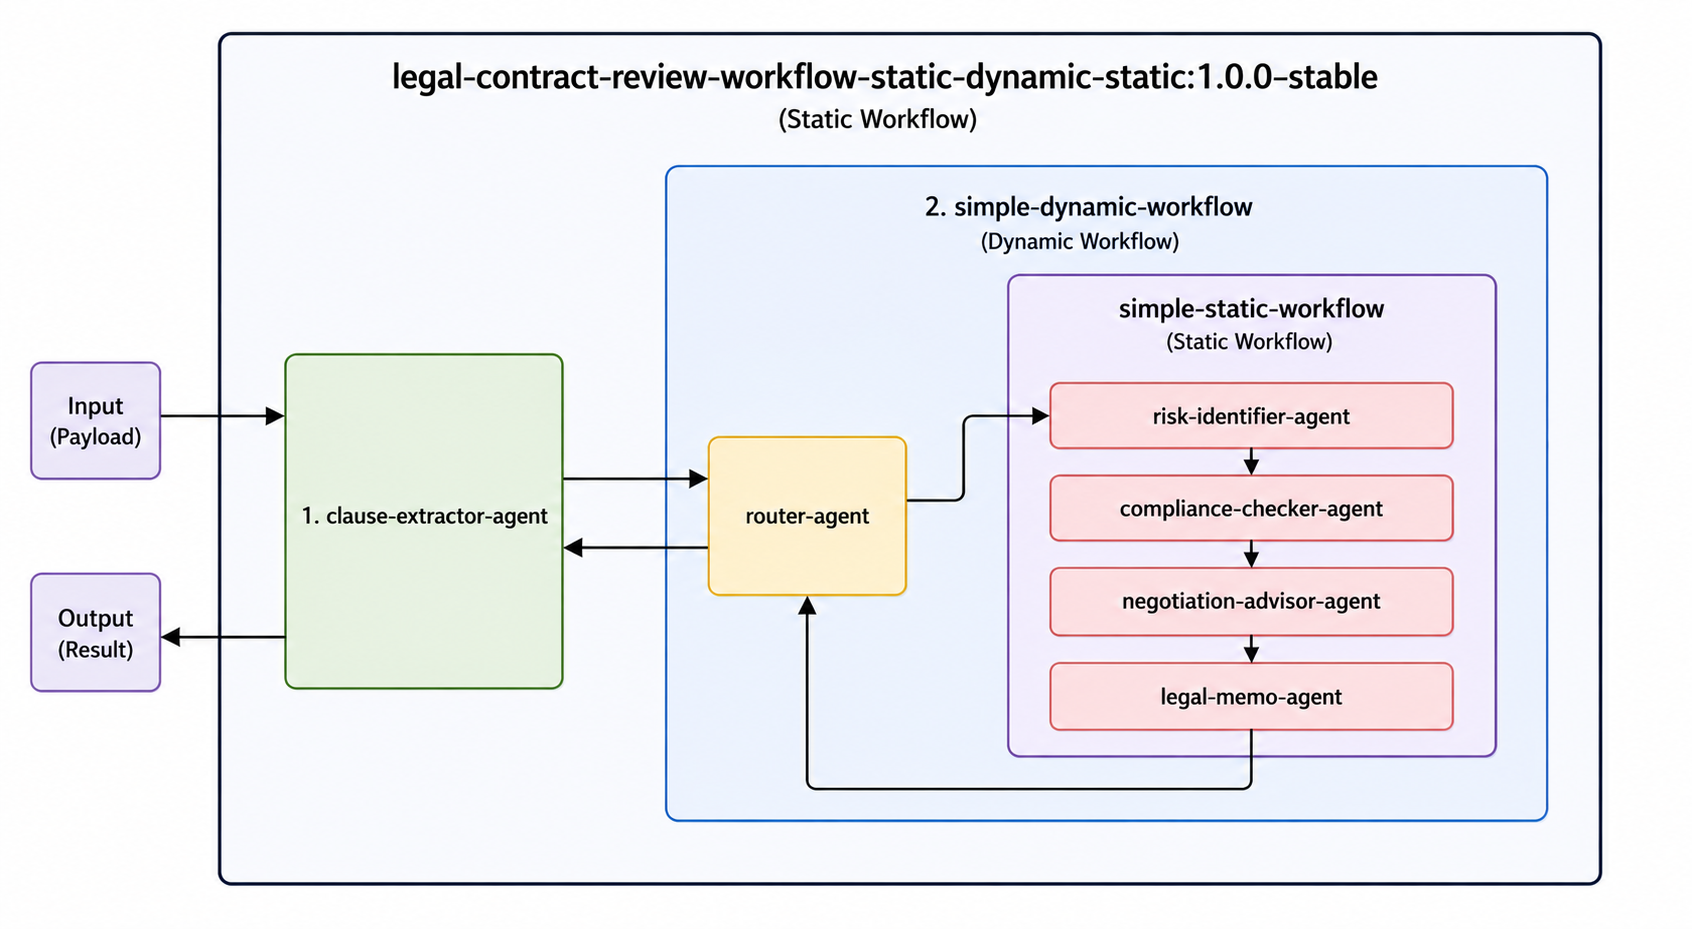

## 2. Register and Build Individual Agents
Before agents can be deployed, they must be registered to the system and packaged as Docker containers.

### Register the agents

In [3]:
%%bash
(
  cd ../spec/
  bash register_agents.sh
)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 10919  100  4087  100  6832   383k   641k --:--:-- --:--:-- --:--:-- 1066k


{"data":{"execution":{"enabled_memory_classes":["short_term","long_term"],"execute_code":false,"logging_level":"INFO","support_delegations":true},"identity":{"subject_id":"clause-extractor-agent","subject_name":"clause-extractor-agent","subject_type":"agent","subject_version":{"release_tag":"stable","version":"1.0.0"}},"info":{"container_image_name":"35.223.239.192:31280/agents/clause-extractor-agent:latest","container_registry_info":"","static_env":{},"static_metadata":{},"static_parameters":{},"static_settings":{}},"integrations":{"addons":[{"addon_config":{"languages":["fr","de","es"]},"addon_id":"translation-addon","addon_type":"translation"}],"builtin_modules":[{"module_description":"Summarizes long documents into concise notes","module_id":"summarizer","module_input_template":"Input: {{text}}","module_management_commands":[{"command":"reset_cache","command_description":"Clears internal caches","input_template":null,"output_template":null}],"module_output_template":"Summary: {{sum

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 10931  100  4093  100  6838   542k   907k --:--:-- --:--:-- --:--:-- 1524k


{"data":{"execution":{"enabled_memory_classes":["short_term","long_term"],"execute_code":false,"logging_level":"INFO","support_delegations":true},"identity":{"subject_id":"compliance-checker-agent","subject_name":"compliance-checker-agent","subject_type":"agent","subject_version":{"release_tag":"stable","version":"1.0.0"}},"info":{"container_image_name":"35.223.239.192:31280/agents/compliance-checker-agent:latest","container_registry_info":"","static_env":{},"static_metadata":{},"static_parameters":{},"static_settings":{}},"integrations":{"addons":[{"addon_config":{"languages":["fr","de","es"]},"addon_id":"translation-addon","addon_type":"translation"}],"builtin_modules":[{"module_description":"Summarizes long documents into concise notes","module_id":"summarizer","module_input_template":"Input: {{text}}","module_management_commands":[{"command":"reset_cache","command_description":"Clears internal caches","input_template":null,"output_template":null}],"module_output_template":"Summary:

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 10883  100  4069  100  6814   536k   898k --:--:-- --:--:-- --:--:-- 1518k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

{"data":{"execution":{"enabled_memory_classes":["short_term","long_term"],"execute_code":false,"logging_level":"INFO","support_delegations":true},"identity":{"subject_id":"legal-memo-agent","subject_name":"legal-memo-agent","subject_type":"agent","subject_version":{"release_tag":"stable","version":"1.0.0"}},"info":{"container_image_name":"35.223.239.192:31280/agents/legal-memo-agent:latest","container_registry_info":"","static_env":{},"static_metadata":{},"static_parameters":{},"static_settings":{}},"integrations":{"addons":[{"addon_config":{"languages":["fr","de","es"]},"addon_id":"translation-addon","addon_type":"translation"}],"builtin_modules":[{"module_description":"Summarizes long documents into concise notes","module_id":"summarizer","module_input_template":"Input: {{text}}","module_management_commands":[{"command":"reset_cache","command_description":"Clears internal caches","input_template":null,"output_template":null}],"module_output_template":"Summary: {{summary}}"}],"contrac

100 10937  100  4096  100  6841   555k   926k --:--:-- --:--:-- --:--:-- 1525k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 10911  100  4083  100  6828   516k   863k --:--:-- --:--:-- --:--:-- 1522k


{"data":{"execution":{"enabled_memory_classes":["short_term","long_term"],"execute_code":false,"logging_level":"INFO","support_delegations":true},"identity":{"subject_id":"negotiation-adviser-agent","subject_name":"negotiation-adviser-agent","subject_type":"agent","subject_version":{"release_tag":"stable","version":"1.0.0"}},"info":{"container_image_name":"35.223.239.192:31280/agents/negotiation-adviser-agent:latest","container_registry_info":"","static_env":{},"static_metadata":{},"static_parameters":{},"static_settings":{}},"integrations":{"addons":[{"addon_config":{"languages":["fr","de","es"]},"addon_id":"translation-addon","addon_type":"translation"}],"builtin_modules":[{"module_description":"Summarizes long documents into concise notes","module_id":"summarizer","module_input_template":"Input: {{text}}","module_management_commands":[{"command":"reset_cache","command_description":"Clears internal caches","input_template":null,"output_template":null}],"module_output_template":"Summa

### Build the docker images and push them to the repository

In [2]:
%%bash
(
  cd ../../
  bash build_single_workflow_and_push.bash
)

Building Docker image with AGENT=clause-extractor-agent -> tag 35.223.239.192:31280/agents/clause-extractor-agent:latest


#0 building with "default" instance using docker driver

#1 [internal] load build definition from Dockerfile
#1 transferring dockerfile: 679B done
#1 DONE 0.0s

#2 [internal] load metadata for docker.io/library/python:3.11-slim
#2 DONE 0.3s

#3 [internal] load .dockerignore
#3 transferring context: 2B done
#3 DONE 0.0s

#4 [1/9] FROM docker.io/library/python:3.11-slim@sha256:d6e4d224f70f9e0172a06a3a2eba2f768eb146811a349278b38fff3a36463b47
#4 DONE 0.0s

#5 [internal] load build context
#5 transferring context: 545.18kB 0.0s done
#5 DONE 0.0s

#6 [2/9] WORKDIR /app
#6 CACHED

#7 [5/9] RUN pip3 install gepa==0.0.24
#7 CACHED

#8 [3/9] COPY requirements.txt /app
#8 CACHED

#9 [4/9] RUN python3 --version
#9 CACHED

#10 [6/9] RUN pip3 install -r requirements.txt
#10 CACHED

#11 [7/9] COPY . /app/
#11 DONE 0.1s

#12 [8/9] COPY entrypoint.sh /usr/local/bin/entrypoint.sh
#12 DONE 0.0s

#13 [9/9] RUN chmod +x /usr/local/bin/entrypoint.sh
#13 DONE 0.2s

#14 exporting to image
#14 exporting layers

Built 35.223.239.192:31280/agents/clause-extractor-agent:latest
The push refers to repository [35.223.239.192:31280/agents/clause-extractor-agent]
55b5183d2879: Preparing
c0f1df03ed73: Preparing
043dfd271a93: Preparing
078e1d8dbe88: Preparing
b6d46d5e6527: Preparing
1c3f53f81eee: Preparing
991fd4d40b5e: Preparing
61f68019bfb5: Preparing
fa1d322086e6: Preparing
5184c31ad48f: Preparing
b0c20bcd44fe: Preparing
a257f20c716c: Preparing
61f68019bfb5: Waiting
fa1d322086e6: Waiting
5184c31ad48f: Waiting
b0c20bcd44fe: Waiting
1c3f53f81eee: Waiting
991fd4d40b5e: Waiting
a257f20c716c: Waiting
b6d46d5e6527: Layer already exists
078e1d8dbe88: Layer already exists
991fd4d40b5e: Layer already exists
1c3f53f81eee: Layer already exists
fa1d322086e6: Layer already exists
61f68019bfb5: Layer already exists
5184c31ad48f: Layer already exists
b0c20bcd44fe: Layer already exists
a257f20c716c: Layer already exists
c0f1df03ed73: Pushed
55b5183d2879: Pushed
043dfd271a93: Pushed
latest: digest: sha256:81f0c1af6b

#0 building with "default" instance using docker driver

#1 [internal] load build definition from Dockerfile
#1 transferring dockerfile: 679B done
#1 DONE 0.0s

#2 [internal] load metadata for docker.io/library/python:3.11-slim
#2 DONE 0.1s

#3 [internal] load .dockerignore
#3 transferring context: 2B done
#3 DONE 0.0s

#4 [1/9] FROM docker.io/library/python:3.11-slim@sha256:d6e4d224f70f9e0172a06a3a2eba2f768eb146811a349278b38fff3a36463b47
#4 DONE 0.0s

#5 [internal] load build context
#5 transferring context: 18.07kB 0.0s done
#5 DONE 0.0s

#6 [7/9] COPY . /app/
#6 CACHED

#7 [5/9] RUN pip3 install gepa==0.0.24
#7 CACHED

#8 [2/9] WORKDIR /app
#8 CACHED

#9 [3/9] COPY requirements.txt /app
#9 CACHED

#10 [6/9] RUN pip3 install -r requirements.txt
#10 CACHED

#11 [4/9] RUN python3 --version
#11 CACHED

#12 [8/9] COPY entrypoint.sh /usr/local/bin/entrypoint.sh
#12 CACHED

#13 [9/9] RUN chmod +x /usr/local/bin/entrypoint.sh
#13 DONE 0.2s

#14 exporting to image
#14 exporting layers 0.0s d

Built 35.223.239.192:31280/agents/compliance-checker-agent:latest
The push refers to repository [35.223.239.192:31280/agents/compliance-checker-agent]
55b5183d2879: Preparing
c0f1df03ed73: Preparing
043dfd271a93: Preparing
078e1d8dbe88: Preparing
b6d46d5e6527: Preparing
1c3f53f81eee: Preparing
991fd4d40b5e: Preparing
61f68019bfb5: Preparing
fa1d322086e6: Preparing
5184c31ad48f: Preparing
b0c20bcd44fe: Preparing
a257f20c716c: Preparing
fa1d322086e6: Waiting
5184c31ad48f: Waiting
b0c20bcd44fe: Waiting
1c3f53f81eee: Waiting
a257f20c716c: Waiting
991fd4d40b5e: Waiting
61f68019bfb5: Waiting
078e1d8dbe88: Layer already exists
b6d46d5e6527: Layer already exists
1c3f53f81eee: Layer already exists
991fd4d40b5e: Layer already exists
61f68019bfb5: Layer already exists
fa1d322086e6: Layer already exists
b0c20bcd44fe: Layer already exists
c0f1df03ed73: Mounted from agents/clause-extractor-agent
5184c31ad48f: Layer already exists
55b5183d2879: Mounted from agents/clause-extractor-agent
043dfd271a93:

...

Built 35.223.239.192:31280/agents/legal-memo-agent:latest
The push refers to repository [35.223.239.192:31280/agents/legal-memo-agent]
0689c0d1127c: Preparing
c0f1df03ed73: Preparing
043dfd271a93: Preparing
078e1d8dbe88: Preparing
b6d46d5e6527: Preparing
1c3f53f81eee: Preparing
991fd4d40b5e: Preparing
61f68019bfb5: Preparing
fa1d322086e6: Preparing
5184c31ad48f: Preparing
b0c20bcd44fe: Preparing
a257f20c716c: Preparing
1c3f53f81eee: Waiting
991fd4d40b5e: Waiting
61f68019bfb5: Waiting
fa1d322086e6: Waiting
5184c31ad48f: Waiting
b0c20bcd44fe: Waiting
a257f20c716c: Waiting
b6d46d5e6527: Layer already exists
078e1d8dbe88: Layer already exists
1c3f53f81eee: Layer already exists
991fd4d40b5e: Layer already exists
61f68019bfb5: Layer already exists
fa1d322086e6: Layer already exists
5184c31ad48f: Layer already exists
b0c20bcd44fe: Layer already exists
c0f1df03ed73: Mounted from agents/compliance-checker-agent
043dfd271a93: Mounted from agents/compliance-checker-agent
a257f20c716c: Layer alrea

#0 building with "default" instance using docker driver

#1 [internal] load build definition from Dockerfile
#1 transferring dockerfile: 679B done
#1 DONE 0.0s

#2 [internal] load metadata for docker.io/library/python:3.11-slim
#2 DONE 0.1s

#3 [internal] load .dockerignore
#3 transferring context: 2B done
#3 DONE 0.0s

#4 [1/9] FROM docker.io/library/python:3.11-slim@sha256:d6e4d224f70f9e0172a06a3a2eba2f768eb146811a349278b38fff3a36463b47
#4 DONE 0.0s

#5 [internal] load build context
#5 transferring context: 18.07kB done
#5 DONE 0.0s

#6 [4/9] RUN python3 --version
#6 CACHED

#7 [7/9] COPY . /app/
#7 CACHED

#8 [3/9] COPY requirements.txt /app
#8 CACHED

#9 [5/9] RUN pip3 install gepa==0.0.24
#9 CACHED

#10 [6/9] RUN pip3 install -r requirements.txt
#10 CACHED

#11 [2/9] WORKDIR /app
#11 CACHED

#12 [8/9] COPY entrypoint.sh /usr/local/bin/entrypoint.sh
#12 CACHED

#13 [9/9] RUN chmod +x /usr/local/bin/entrypoint.sh
#13 DONE 0.2s

#14 exporting to image
#14 exporting layers 0.0s done
#

Built 35.223.239.192:31280/agents/negotiation-adviser-agent:latest
The push refers to repository [35.223.239.192:31280/agents/negotiation-adviser-agent]
9e9c8e08953b: Preparing
c0f1df03ed73: Preparing
043dfd271a93: Preparing
078e1d8dbe88: Preparing
b6d46d5e6527: Preparing
1c3f53f81eee: Preparing
991fd4d40b5e: Preparing
61f68019bfb5: Preparing
fa1d322086e6: Preparing
5184c31ad48f: Preparing
b0c20bcd44fe: Preparing
a257f20c716c: Preparing
991fd4d40b5e: Waiting
61f68019bfb5: Waiting
fa1d322086e6: Waiting
5184c31ad48f: Waiting
b0c20bcd44fe: Waiting
a257f20c716c: Waiting
1c3f53f81eee: Waiting
078e1d8dbe88: Layer already exists
b6d46d5e6527: Layer already exists
1c3f53f81eee: Layer already exists
991fd4d40b5e: Layer already exists
61f68019bfb5: Layer already exists
fa1d322086e6: Layer already exists
5184c31ad48f: Layer already exists
043dfd271a93: Mounted from agents/legal-memo-agent
c0f1df03ed73: Mounted from agents/legal-memo-agent
b0c20bcd44fe: Layer already exists
a257f20c716c: Layer alr

#0 building with "default" instance using docker driver

#1 [internal] load build definition from Dockerfile
#1 transferring dockerfile: 679B done
#1 DONE 0.0s

#2 [internal] load metadata for docker.io/library/python:3.11-slim
#2 DONE 0.1s

#3 [internal] load .dockerignore
#3 transferring context: 2B done
#3 DONE 0.0s

#4 [1/9] FROM docker.io/library/python:3.11-slim@sha256:d6e4d224f70f9e0172a06a3a2eba2f768eb146811a349278b38fff3a36463b47
#4 DONE 0.0s

#5 [internal] load build context
#5 transferring context: 18.07kB 0.0s done
#5 DONE 0.0s

#6 [3/9] COPY requirements.txt /app
#6 CACHED

#7 [5/9] RUN pip3 install gepa==0.0.24
#7 CACHED

#8 [4/9] RUN python3 --version
#8 CACHED

#9 [7/9] COPY . /app/
#9 CACHED

#10 [2/9] WORKDIR /app
#10 CACHED

#11 [6/9] RUN pip3 install -r requirements.txt
#11 CACHED

#12 [8/9] COPY entrypoint.sh /usr/local/bin/entrypoint.sh
#12 CACHED

#13 [9/9] RUN chmod +x /usr/local/bin/entrypoint.sh
#13 DONE 0.2s

#14 exporting to image
#14 exporting layers done
#

Built 35.223.239.192:31280/agents/risk-identifier-agent:latest
The push refers to repository [35.223.239.192:31280/agents/risk-identifier-agent]
9e9c8e08953b: Preparing
c0f1df03ed73: Preparing
043dfd271a93: Preparing
078e1d8dbe88: Preparing
b6d46d5e6527: Preparing
1c3f53f81eee: Preparing
991fd4d40b5e: Preparing
61f68019bfb5: Preparing
fa1d322086e6: Preparing
5184c31ad48f: Preparing
b0c20bcd44fe: Preparing
a257f20c716c: Preparing
fa1d322086e6: Waiting
1c3f53f81eee: Waiting
991fd4d40b5e: Waiting
61f68019bfb5: Waiting
5184c31ad48f: Waiting
b0c20bcd44fe: Waiting
a257f20c716c: Waiting
b6d46d5e6527: Layer already exists
078e1d8dbe88: Layer already exists
1c3f53f81eee: Layer already exists
991fd4d40b5e: Layer already exists
61f68019bfb5: Layer already exists
fa1d322086e6: Layer already exists
c0f1df03ed73: Mounted from agents/negotiation-adviser-agent
9e9c8e08953b: Mounted from agents/negotiation-adviser-agent
b0c20bcd44fe: Layer already exists
043dfd271a93: Mounted from agents/negotiation-ad

## 3. Deploy Agents
Once the images are built and pushed, deploy the agents into the cluster so they are actively waiting for tasks.

### Deploy the agents into the cluster

In [5]:
%%bash
(
  cd ../spec/
  bash deploy_agents.sh
)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   911  100   561  100   350   4938   3081 --:--:-- --:--:-- --:--:--  7991


{"data":{"runtime_info":{"deployment_data":{"executor":{"cluster_ip":"10.111.22.17","node_port":30840,"port":9000,"service_name":"executor-clause-extractor-agent-executor-svc"},"name":"executor-clause-extractor-agent","scouter":{"cluster_ip":"10.111.19.168","node_port":32556,"port":10000,"service_name":"executor-clause-extractor-agent-scouter-svc"}},"executor":"http://35.223.239.192:30840","scouter":"http://35.223.239.192:32556"},"runtime_status":"active","runtime_subject_id":"clause-extractor-agent","subject_id":"clause-extractor-agent"},"success":true}


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   926  100   572  100   354   5908   3656 --:--:-- --:--:-- --:--:--  9645


{"data":{"runtime_info":{"deployment_data":{"executor":{"cluster_ip":"10.103.105.236","node_port":30402,"port":9000,"service_name":"executor-compliance-checker-agent-executor-svc"},"name":"executor-compliance-checker-agent","scouter":{"cluster_ip":"10.105.43.72","node_port":31353,"port":10000,"service_name":"executor-compliance-checker-agent-scouter-svc"}},"executor":"http://35.223.239.192:30402","scouter":"http://35.223.239.192:31353"},"runtime_status":"active","runtime_subject_id":"compliance-checker-agent","subject_id":"compliance-checker-agent"},"success":true}


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   870  100   532  100   338   6094   3871 --:--:-- --:--:-- --:--:-- 10000


{"data":{"runtime_info":{"deployment_data":{"executor":{"cluster_ip":"10.109.74.65","node_port":31174,"port":9000,"service_name":"executor-legal-memo-agent-executor-svc"},"name":"executor-legal-memo-agent","scouter":{"cluster_ip":"10.108.131.211","node_port":30861,"port":10000,"service_name":"executor-legal-memo-agent-scouter-svc"}},"executor":"http://35.223.239.192:31174","scouter":"http://35.223.239.192:30861"},"runtime_status":"active","runtime_subject_id":"legal-memo-agent","subject_id":"legal-memo-agent"},"success":true}


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   933  100   577  100   356   7273   4487 --:--:-- --:--:-- --:--:-- 11810


{"data":{"runtime_info":{"deployment_data":{"executor":{"cluster_ip":"10.96.48.171","node_port":31111,"port":9000,"service_name":"executor-negotiation-adviser-agent-executor-svc"},"name":"executor-negotiation-adviser-agent","scouter":{"cluster_ip":"10.103.210.214","node_port":31296,"port":10000,"service_name":"executor-negotiation-adviser-agent-scouter-svc"}},"executor":"http://35.223.239.192:31111","scouter":"http://35.223.239.192:31296"},"runtime_status":"active","runtime_subject_id":"negotiation-adviser-agent","subject_id":"negotiation-adviser-agent"},"success":true}


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   906  100   558  100   348   5530   3448 --:--:-- --:--:-- --:--:--  9060


{"data":{"runtime_info":{"deployment_data":{"executor":{"cluster_ip":"10.105.146.180","node_port":32094,"port":9000,"service_name":"executor-risk-identifier-agent-executor-svc"},"name":"executor-risk-identifier-agent","scouter":{"cluster_ip":"10.111.106.31","node_port":30168,"port":10000,"service_name":"executor-risk-identifier-agent-scouter-svc"}},"executor":"http://35.223.239.192:32094","scouter":"http://35.223.239.192:30168"},"runtime_status":"active","runtime_subject_id":"risk-identifier-agent","subject_id":"risk-identifier-agent"},"success":true}


### Verify that the agents are running

In [17]:
!kubectl get pods -n agents

2026/03/13 09:36:30 Starlark failed to allocate 4GB address space: cannot allocate memory. Integer performance may suffer.
NAME                                                 READY   STATUS        RESTARTS      AGE
executor-clause-extractor-agent-bc7d99865-hbjbt      3/3     Terminating   0             31m
executor-compliance-checker-agent-fd4f56d54-vklgb    3/3     Terminating   0             31m
executor-legal-memo-agent-9957dbb59-hkd6w            3/3     Terminating   0             31m
executor-negotiation-adviser-agent-6f6657df7-8bz98   3/3     Terminating   0             31m
executor-risk-identifier-agent-798dc6854b-nm86f      3/3     Terminating   0             31m
executor-uppercase-004-748f8c69c7-kmmnp              3/3     Running       0             4d14h
executor-w1-clause-1-5ffb855596-4t9zn                3/3     Running       1 (45h ago)   45h
executor-w1-comp-1-c48c5cf4b-95fnj                   3/3     Running       0             2d3h
executor-w1-memo-1-5ccbcd5b7f-nrlhp  

## 4. Register and Deploy the Workflow
The `workflow_spec.json` defines how the outputs of one agent map dynamically to the inputs of the next agent. We need to register this spec and deploy it.

### Register the workflow

In [7]:
%%bash
(
  bash register_workflow.sh
)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  3027  100  1303  100  1724   155k   205k --:--:-- --:--:-- --:--:--  369k


{"data":{"body":{"graph":{"my-clause-extractor-agent":["my-risk-identifier-agent"],"my-compliance-checker-agent":["my-negotiation-advisor-agent"],"my-negotiation-advisor-agent":["my-legal-memo-agent"],"my-risk-identifier-agent":["my-compliance-checker-agent"]},"nodes":[{"id":"clause-extractor-agent","nodeID":"my-clause-extractor-agent","settings":{"model_name":"aios:qwen3-1-7b-vllm-block"},"type":"agent"},{"id":"risk-identifier-agent","nodeID":"my-risk-identifier-agent","settings":{"model_name":"aios:qwen3-1-7b-vllm-block"},"type":"agent"},{"id":"compliance-checker-agent","nodeID":"my-compliance-checker-agent","settings":{"model_name":"aios:qwen3-1-7b-vllm-block"},"type":"agent"},{"id":"negotiation-adviser-agent","nodeID":"my-negotiation-advisor-agent","settings":{"model_name":"aios:qwen3-1-7b-vllm-block"},"type":"agent"},{"id":"legal-memo-agent","nodeID":"my-legal-memo-agent","settings":{"model_name":"aios:qwen3-1-7b-vllm-block"},"type":"agent"}]},"header":{"metadata":{"created_at":"2

### Deploy the workflow to establish connections
This creates a central coordinator for the workflow which acts like a Controller co-ordinating between different agents based on workflow defined. It provides API URLs for interacting with input or any other task of workflow

In [9]:
%%bash
(
  bash deploy_workflow.sh
)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   569  100   255  100   314   3369   4148 --:--:-- --:--:-- --:--:--  7586


{"data":{"cluster_id":null,"deployer_id":"deployer-111","deployment_name":"simple-sequential-workflow","id":"simple-sequential-workflow-001","url":"http://35.223.239.192:31991","workflow_uri":"legal-contract-review-workflow:1.0.0-stable"},"success":true}


### Verify that the workflow pods are running

In [14]:
!kubectl get pods -n workflows

2026/03/13 09:35:19 Starlark failed to allocate 4GB address space: cannot allocate memory. Integer performance may suffer.
NAME                                          READY   STATUS             RESTARTS           AGE
simple-sequential-workflow-59c6dbd649-b6ft2   1/1     Terminating        0                  7m29s
simple-workflow-66b666f4bd-bfsjh              1/1     Running            1 (45h ago)        45h
work-123-858d58c79d-f6756                     0/1     CrashLoopBackOff   1309 (2m33s ago)   4d15h
work-124-6674584657-fnmzc                     1/1     Running            0                  2d3h


## 5. Run the Workflow Demo
With everything deployed, start the Streamlit Dashboard to visualize the flow, and feed the initial payload into the first agent.

### Run the Streamlit app in the background

In [11]:
%%bash
(
  source ../../../agent_codes/venv/bin/activate
  nohup bash run_streamlit_app.bash > streamlit.log 2>&1 &
  echo "Dashboard starting in background..."
)

Dashboard starting in background...


### Trigger the inference by sending a contract to the workflow inbox

In [12]:
%%bash
(
  bash workflow_input.sh
)

Executing workflow at http://35.223.239.192:31991


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   328    0     0  100   328      0      5  0:01:05  0:00:56  0:00:09     0

{"data":{"my-clause-extractor-agent":{"clause_count":7,"clauses":{"data_ownership":"Data ownership ambiguous","jurisdiction":"Jurisdiction: Delaware, USA","liability":"Liability cap at $5,000 regardless of contract value ($2M/year)","payment":"Auto-renewal at 15% price increase, no SLA guarantees","renewal":"Auto-renewal at 15% price increase","sla":"No SLA guarantees","termination":"Termination requires 180-day notice"},"raw_contract":"Contract: SaaS Subscription Agreement between Acme Corp (vendor) and RetailCo (client). Key clauses: auto-renewal at 15% price increase, no SLA guarantees, data ownership ambiguous, termination requires 180-day notice, liability cap at $5,000 regardless of contract value ($2M/year). Jurisdiction: Delaware, USA."},"my-compliance-checker-agent":{"clauses":{"data_ownership":"Data ownership ambiguous","jurisdiction":"Jurisdiction: Delaware, USA","liability":"Liability cap at $5,000 regardless of contract value ($2M/year)","payment":"Auto-renewal at 15% pric

100 15515  100 15187  100   328    270      5  0:01:05  0:00:56  0:00:09  3767


## 6. Clean Up and Destroy Resources
Once the demonstration is complete, cleanly tear down the resources.

### Remove workflow connections and coordinator pods

In [13]:
%%bash
(
  bash remove_workflow.sh
)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    61  100    56  100     5    974     87 --:--:-- --:--:-- --:--:--  1070


{"data":"Workflow removed successfully","success":true}


### Unregister the workflow entirely

In [15]:
%%bash
(
  bash unregister_workflow.sh
)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    47  100    47    0     0   6216      0 --:--:-- --:--:-- --:--:--  6714


{"data":"deleted successfully","success":true}


### Remove the agent pods

In [16]:
%%bash
(
  cd ../spec
  bash remove_agents.sh
)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    47  100    47    0     0    667      0 --:--:-- --:--:-- --:--:--   671


{"data":"removed successfully","success":true}


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    47  100    47    0     0    818      0 --:--:-- --:--:-- --:--:--   824


{"data":"removed successfully","success":true}


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    47  100    47    0     0    970      0 --:--:-- --:--:-- --:--:--   979


{"data":"removed successfully","success":true}


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    47  100    47    0     0    653      0 --:--:-- --:--:-- --:--:--   661


{"data":"removed successfully","success":true}


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    47  100    47    0     0   1169      0 --:--:-- --:--:-- --:--:--  1175


{"data":"removed successfully","success":true}


### Unregister the individual agents from the AgentGrid system

In [18]:
%%bash
(
  cd ../spec
  bash unregister_agents.sh
)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    41  100    41    0     0   5000      0 --:--:-- --:--:-- --:--:--  5125


{"data":{"deleted":true},"success":true}


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    41  100    41    0     0   6850      0 --:--:-- --:--:-- --:--:--  8200


{"data":{"deleted":true},"success":true}


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    41  100    41    0     0   7557      0 --:--:-- --:--:-- --:--:--  8200


{"data":{"deleted":true},"success":true}


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    41  100    41    0     0   7693      0 --:--:-- --:--:-- --:--:--  8200


{"data":{"deleted":true},"success":true}


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    41  100    41    0     0   8159      0 --:--:-- --:--:-- --:--:--  8200


{"data":{"deleted":true},"success":true}
